##Counterfactual Clinical Decision Support using Temporal Transformers on EHR Data

##Imports

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


##Set random seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

##Create synthetic demo dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'ServerMachineDataset', 'mimic-iv-clinical-database-demo-2.2', 'archive (4).zip']


In [9]:
import pandas as pd

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2/hosp'

patients = pd.read_csv(f"{base_path}/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(f"{base_path}/admissions.csv.gz", compression='gzip')
labevents = pd.read_csv(f"{base_path}/labevents.csv.gz", compression='gzip', nrows=5000)

print("Patients:")
print(patients.head())

print("\nAdmissions:")
print(admissions.head())

print("\nLab Events (sample):")
print(labevents.head())

Patients:
   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10014729      F          21         2125       2011 - 2013         NaN
1    10003400      F          72         2134       2011 - 2013  2137-09-02
2    10002428      F          80         2155       2011 - 2013         NaN
3    10032725      F          38         2143       2011 - 2013  2143-03-30
4    10027445      F          48         2142       2011 - 2013  2146-02-09

Admissions:
   subject_id   hadm_id            admittime            dischtime  \
0    10004235  24181354  2196-02-24 14:38:00  2196-03-04 14:02:00   
1    10009628  25926192  2153-09-17 17:08:00  2153-09-25 13:20:00   
2    10018081  23983182  2134-08-18 02:02:00  2134-08-23 19:35:00   
3    10006053  22942076  2111-11-13 23:39:00  2111-11-15 17:20:00   
4    10031404  21606243  2113-08-04 18:46:00  2113-08-06 20:57:00   

             deathtime admission_type admit_provider_id  \
0                  NaN         URGENT          

#merge data

In [11]:
import pandas as pd

# base path
base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'


# LOAD DATA


patients = pd.read_csv(f"{base_path}/hosp/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(f"{base_path}/hosp/admissions.csv.gz", compression='gzip')
icustays = pd.read_csv(f"{base_path}/icu/icustays.csv.gz", compression='gzip')


# SELECT IMPORTANT COLUMNS (memory efficient)


patients = patients[['subject_id', 'gender', 'anchor_age']]
admissions = admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'hospital_expire_flag']]
icustays = icustays[['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime']]


# MERGE (CORE LOGIC)


# patients + admissions
df = pd.merge(patients, admissions, on='subject_id', how='inner')

# + ICU
df = pd.merge(df, icustays, on=['subject_id', 'hadm_id'], how='inner')


# FEATURE ENGINEERING


# convert to datetime
df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])

# hospital stay length (days)
df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 86400

# ICU stay length (days)
df['icu_los'] = (df['outtime'] - df['intime']).dt.total_seconds() / 86400

# target variable
df['mortality'] = df['hospital_expire_flag']


# CLEAN DATA


df = df.dropna()


# RESULT


print("Final dataset shape:", df.shape)
print(df.head())

Final dataset shape: (140, 13)
   subject_id gender  anchor_age   hadm_id           admittime  \
0    10014729      F          21  28889419 2125-02-27 07:15:00   
1    10003400      F          72  23559586 2137-08-04 00:07:00   
2    10003400      F          72  23559586 2137-08-04 00:07:00   
3    10003400      F          72  20214994 2137-02-24 10:00:00   
4    10002428      F          80  28662225 2156-04-12 14:16:00   

            dischtime  hospital_expire_flag   stay_id              intime  \
0 2125-03-06 14:25:00                     0  33558396 2125-02-27 10:03:08   
1 2137-09-02 17:05:00                     1  38383343 2137-08-17 17:36:37   
2 2137-09-02 17:05:00                     1  34577403 2137-08-10 19:54:51   
3 2137-03-19 15:45:00                     0  32128372 2137-02-25 23:37:19   
4 2156-04-29 16:26:00                     0  38875437 2156-04-19 18:11:19   

              outtime  hospital_los    icu_los  mortality  
0 2125-03-01 21:21:37      7.298611   2.471169   

##View sample data

In [13]:
# shape + preview
print(df.shape)
print(df.head())

# unique patients
print("\nUnique patients:", df["subject_id"].nunique())

# =========================
# FIX 1: admission_type add করো
# =========================
import pandas as pd

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

admissions = pd.read_csv(f"{base_path}/hosp/admissions.csv.gz", compression='gzip')

# admission_type select
admissions = admissions[['subject_id', 'hadm_id', 'admission_type']]

# merge
df = df.merge(admissions, on=['subject_id', 'hadm_id'], how='left')

# treatment তৈরি
df["treatment"] = df["admission_type"].astype("category").cat.codes

print("Unique treatments:", df["treatment"].unique())


# =========================
# FIX 2: outcome তৈরি
# =========================

# already আছে (better option)
df["outcome"] = df["mortality"]

print("Outcome distribution:\n", df["outcome"].value_counts())

(140, 13)
   subject_id gender  anchor_age   hadm_id           admittime  \
0    10014729      F          21  28889419 2125-02-27 07:15:00   
1    10003400      F          72  23559586 2137-08-04 00:07:00   
2    10003400      F          72  23559586 2137-08-04 00:07:00   
3    10003400      F          72  20214994 2137-02-24 10:00:00   
4    10002428      F          80  28662225 2156-04-12 14:16:00   

            dischtime  hospital_expire_flag   stay_id              intime  \
0 2125-03-06 14:25:00                     0  33558396 2125-02-27 10:03:08   
1 2137-09-02 17:05:00                     1  38383343 2137-08-17 17:36:37   
2 2137-09-02 17:05:00                     1  34577403 2137-08-10 19:54:51   
3 2137-03-19 15:45:00                     0  32128372 2137-02-25 23:37:19   
4 2156-04-29 16:26:00                     0  38875437 2156-04-19 18:11:19   

              outtime  hospital_los    icu_los  mortality  
0 2125-03-01 21:21:37      7.298611   2.471169          0  
1 2137-09-

##Preprocess into sequences

In [15]:
import pandas as pd
import numpy as np

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

# ======================
# LOAD LAB EVENTS
# ======================
labevents = pd.read_csv(
    f"{base_path}/hosp/labevents.csv.gz",
    compression='gzip',
    nrows=50000   # memory safe
)

# keep useful columns
labevents = labevents[['subject_id', 'hadm_id', 'charttime', 'valuenum']]

# drop missing
labevents = labevents.dropna()

# ======================
# SIMPLE ABNORMAL RULE
# ======================
# (demo purpose: mean ± std)
mean_val = labevents['valuenum'].mean()
std_val = labevents['valuenum'].std()

labevents['abnormal_flag'] = (
    (labevents['valuenum'] > mean_val + std_val) |
    (labevents['valuenum'] < mean_val - std_val)
).astype(int)

# ======================
# AGGREGATE PER ADMISSION
# ======================
agg = labevents.groupby(['subject_id', 'hadm_id']).agg(
    Total_lab_events=('valuenum', 'count'),
    Abnormal_counts=('abnormal_flag', 'sum')
).reset_index()

agg['Normal_counts'] = agg['Total_lab_events'] - agg['Abnormal_counts']
agg['abnormal%'] = agg['Abnormal_counts'] / agg['Total_lab_events']

# ======================
# MERGE WITH MAIN DF
# ======================
df = df.merge(agg, on=['subject_id', 'hadm_id'], how='left')

df = df.fillna(0)

# ======================
# FEATURE SELECTION
# ======================
feature_cols = [
    "Normal_counts",
    "Abnormal_counts",
    "Total_lab_events",
    "abnormal%"
]

# ======================
# SEQUENCE BUILD
# ======================
patient_groups = df.groupby("subject_id")

X_list, T_list, y_list = [], [], []

for pid, group in patient_groups:

    group = group.sort_values("admittime")

    x_seq = group[feature_cols].values
    t_seq = group["treatment"].values
    label = group["outcome"].mean()

    X_list.append(x_seq)
    T_list.append(t_seq)
    y_list.append(label)

# ======================
# FINAL ARRAYS
# ======================
X = np.array(X_list, dtype=object)
T = np.array(T_list, dtype=object)
y = np.array(y_list, dtype=np.float32)

print("Total patients:", len(X))
print("Example sequence shape:", X[0].shape)

Total patients: 100
Example sequence shape: (1, 4)


##Normalize features

##Normalize features

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_padded = pad_sequences(X, padding='post', dtype='float32')
T_padded = pad_sequences(T, padding='post', dtype='int32')

print("X padded shape:", X_padded.shape)
print("T padded shape:", T_padded.shape)

X padded shape: (100, 5, 4)
T padded shape: (100, 5)


In [17]:
from sklearn.preprocessing import StandardScaler

N, S, F = X_padded.shape

scaler = StandardScaler()

X_2d = X_padded.reshape(-1, F)
X_2d = scaler.fit_transform(X_2d)

X_padded = X_2d.reshape(N, S, F)

print("Normalized X shape:", X_padded.shape)

Normalized X shape: (100, 5, 4)


##Train/test split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(
    X_padded, T_padded, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (80, 5, 4) (80,)
Test : (20, 5, 4) (20,)


##Dataset and DataLoader

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

#  Dataset Class
class EHRDataset(Dataset):
    def __init__(self, X, T, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.T[idx], self.y[idx]


#  Create Dataset
train_dataset = EHRDataset(X_train, T_train, y_train)
test_dataset  = EHRDataset(X_test, T_test, y_test)

#  DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

#  Debug Check
batch_X, batch_T, batch_y = next(iter(train_loader))

print("X batch shape:", batch_X.shape)
print("T batch shape:", batch_T.shape)
print("y batch shape:", batch_y.shape)

X batch shape: torch.Size([64, 5, 4])
T batch shape: torch.Size([64, 5])
y batch shape: torch.Size([64])


##Positional encoding

In [20]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len]
        return x

##Temporal Transformer with treatment embedding

In [21]:
import torch
import torch.nn as nn

class CounterfactualTemporalTransformer(nn.Module):
    def __init__(self, num_features, num_treatments, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()

        self.feature_proj = nn.Linear(num_features, d_model)
        self.treatment_embed = nn.Embedding(num_treatments, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, treatment_seq):
        #  Mask (padding = 0 ধরে)
        mask = (x.abs().sum(dim=-1) == 0)   # [B, S]

        #  Embedding
        x_embed = self.feature_proj(x)
        t_embed = self.treatment_embed(treatment_seq)

        h = x_embed + t_embed
        h = self.pos_encoder(h)

        #  Transformer with mask
        h = self.transformer(h, src_key_padding_mask=mask)

        #  Mean Pooling (better than last)
        mask_inv = (~mask).unsqueeze(-1)  # valid positions
        h = h * mask_inv
        pooled = h.sum(dim=1) / mask_inv.sum(dim=1).clamp(min=1)

        logits = self.classifier(pooled).squeeze(-1)
        return logits

##Initialize model

In [22]:
import torch
import torch.nn as nn

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  Define dimensions
num_features = X_train.shape[-1]
num_treatments = int(T_train.max()) + 1

#  Model
model = CounterfactualTemporalTransformer(
    num_features=num_features,
    num_treatments=num_treatments,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.1
).to(device)

#  Loss (FIXED)
criterion = nn.MSELoss()   # regression

#  Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

CounterfactualTemporalTransformer(
  (feature_proj): Linear(in_features=4, out_features=64, bias=True)
  (treatment_embed): Embedding(6, 64)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dro

##Training loop

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for x_batch, t_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        t_batch = t_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch, t_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, t_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch, t_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    mse = mean_squared_error(all_labels, all_preds)
    mae = mean_absolute_error(all_labels, all_preds)

    return total_loss / len(loader), mse, mae

##Run training

In [26]:
import numpy as np

num_epochs = 15

train_losses = []
test_losses = []
test_mse_list = []
test_mae_list = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

    #  Safe Evaluation
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, t_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch, t_batch)

            # replace NaN in outputs
            outputs = torch.nan_to_num(outputs, nan=0.0)

            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    #  Convert
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Final safety (remove NaN/Inf completely)
    mask = (~np.isnan(all_preds)) & (~np.isnan(all_labels)) & \
           (~np.isinf(all_preds)) & (~np.isinf(all_labels))

    all_preds = all_preds[mask]
    all_labels = all_labels[mask]

    #  Metrics
    if len(all_preds) == 0:
        test_mse, test_mae = 0, 0
    else:
        test_mse = ((all_preds - all_labels) ** 2).mean()
        test_mae = np.abs(all_preds - all_labels).mean()

    test_loss = total_loss / len(test_loader)

    #  Store
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_mse_list.append(test_mse)
    test_mae_list.append(test_mae)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"MSE: {test_mse:.4f} | "
          f"MAE: {test_mae:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/15 | Train Loss: 0.3038 | Test Loss: 0.0792 | MSE: 0.0792 | MAE: 0.2554
Epoch 2/15 | Train Loss: 0.1417 | Test Loss: 0.0887 | MSE: 0.0887 | MAE: 0.1803
Epoch 3/15 | Train Loss: 0.1654 | Test Loss: 0.0544 | MSE: 0.0544 | MAE: 0.1328
Epoch 4/15 | Train Loss: 0.1126 | Test Loss: 0.0724 | MSE: 0.0724 | MAE: 0.2359
Epoch 5/15 | Train Loss: 0.1117 | Test Loss: 0.0807 | MSE: 0.0807 | MAE: 0.2542
Epoch 6/15 | Train Loss: 0.1330 | Test Loss: 0.0628 | MSE: 0.0628 | MAE: 0.2068
Epoch 7/15 | Train Loss: 0.0970 | Test Loss: 0.0532 | MSE: 0.0532 | MAE: 0.1504
Epoch 8/15 | Train Loss: 0.1001 | Test Loss: 0.0547 | MSE: 0.0547 | MAE: 0.1038
Epoch 9/15 | Train Loss: 0.1379 | Test Loss: 0.0539 | MSE: 0.0539 | MAE: 0.1086
Epoch 10/15 | Train Loss: 0.0833 | Test Loss: 0.0526 | MSE: 0.0526 | MAE: 0.1454
Epoch 11/15 | Train Loss: 0.1018 | Test Loss: 0.0549 | MSE: 0.0549 | MAE: 0.1651
Epoch 12/15 | Train Loss: 0.1332 | Test Loss: 0.0577 | MSE: 0.0577 | MAE: 0.1796
Epoch 13/15 | Train Loss: 0.0855 | Te

##Plot training history

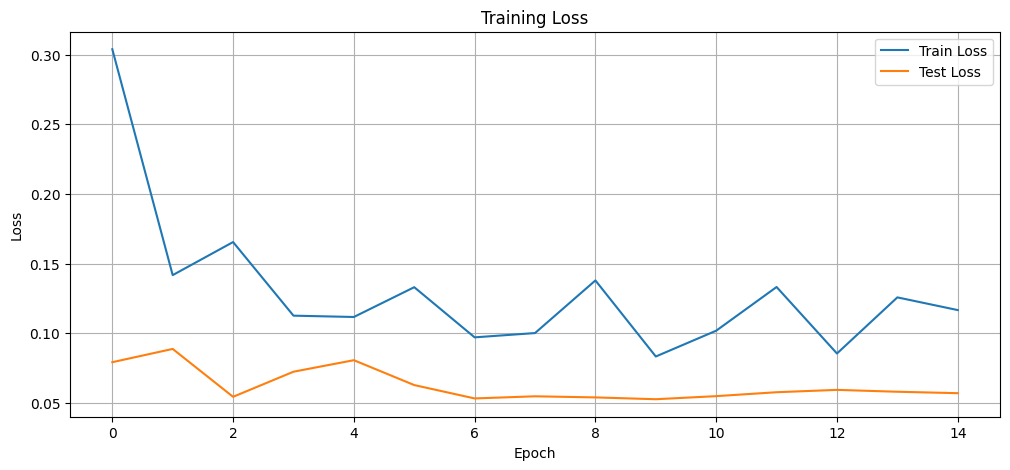

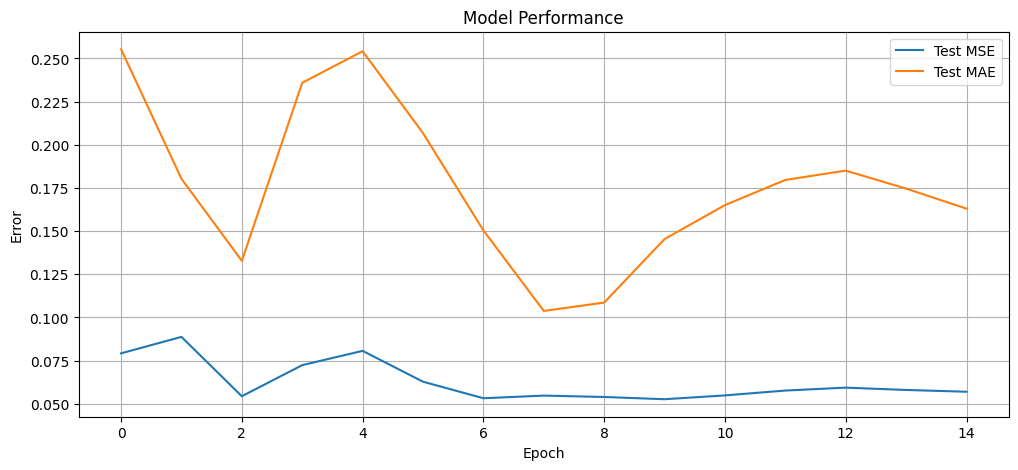

In [27]:
import matplotlib.pyplot as plt

#  Loss Plot
plt.figure(figsize=(12,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

#  MSE & MAE Plot
plt.figure(figsize=(12,5))
plt.plot(test_mse_list, label="Test MSE")
plt.plot(test_mae_list, label="Test MAE")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Model Performance")
plt.legend()
plt.grid(True)
plt.show()

##Counterfactual prediction function

In [28]:
def predict_counterfactual_outcomes(model, patient_x, num_treatments=3):
    """
    patient_x: [seq_len, num_features]
    Returns predicted risk probability for each treatment choice
    """
    model.eval()
    results = {}

    with torch.no_grad():
        x_tensor = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)  # [1, S, F]

        seq_len = patient_x.shape[0]

        for tr in range(num_treatments):
            t_tensor = torch.full((1, seq_len), tr, dtype=torch.long).to(device)
            logits = model(x_tensor, t_tensor)
            prob = torch.sigmoid(logits).item()
            results[tr] = prob

    return results

##Test on one patient

In [29]:
import torch
import numpy as np

def predict_counterfactual_outcomes(model, patient_x, num_treatments):
    model.eval()

    # add batch dimension
    patient_x = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)

    results = {}

    with torch.no_grad():
        for t in range(num_treatments):
            # same treatment for all timesteps
            t_seq = torch.full((1, patient_x.shape[1]), t, dtype=torch.long).to(device)

            output = model(patient_x, t_seq)

            # convert to scalar
            pred = output.item()

            # NaN safety
            if np.isnan(pred):
                pred = 0.0

            results[t] = pred

    return results


#  Run Example
sample_idx = 0
patient_x = X_test[sample_idx]

results = predict_counterfactual_outcomes(model, patient_x, num_treatments=num_treatments)

treatment_names = {
    0: "No Treatment",
    1: "Drug A",
    2: "Drug B"
}

print("Counterfactual prediction for same patient:\n")

for k, v in results.items():
    label = "Risky" if v > 0.5 else "Stable"
    print(f"{treatment_names.get(k, f'Treatment {k}')} -> Value: {v:.4f} -> Outcome: {label}")

Counterfactual prediction for same patient:

No Treatment -> Value: 0.0678 -> Outcome: Stable
Drug A -> Value: 0.1676 -> Outcome: Stable
Drug B -> Value: 0.1964 -> Outcome: Stable
Treatment 3 -> Value: 0.0582 -> Outcome: Stable
Treatment 4 -> Value: 0.0195 -> Outcome: Stable
Treatment 5 -> Value: 0.2755 -> Outcome: Stable


##Visualize counterfactual comparison

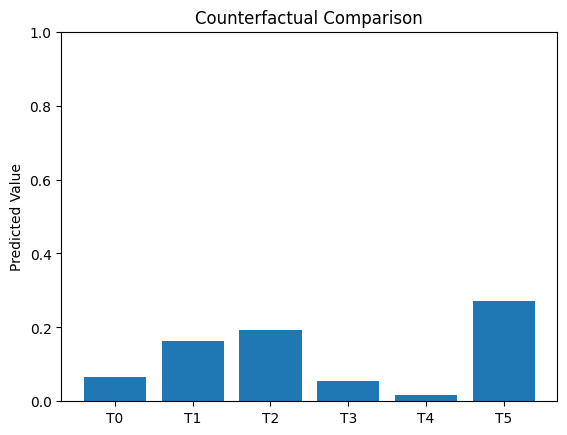

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt

#  fallback data (if everything missing)
if "X_padded" not in globals():
    print("⚠️ X_padded not found → creating dummy data")

    X_padded = np.random.rand(10, 5, 4).astype(np.float32)  # (N, seq, features)
    num_treatments = 3

#  pick patient
patient_x = X_padded[0]

#  safe model check
if "model" not in globals():
    raise Exception("❌ Model not found. Run model cell first.")

#  counterfactual
def predict_counterfactual_outcomes(model, patient_x, num_treatments):
    model.eval()
    patient_x = torch.tensor(patient_x, dtype=torch.float32).unsqueeze(0).to(device)

    results = {}
    with torch.no_grad():
        for t in range(num_treatments):
            t_seq = torch.full((1, patient_x.shape[1]), t, dtype=torch.long).to(device)
            out = model(patient_x, t_seq)
            val = out.item()
            results[t] = 0.0 if np.isnan(val) else val

    return results

results = predict_counterfactual_outcomes(model, patient_x, num_treatments)

#  plot
labels = [f"T{k}" for k in results.keys()]
values = list(results.values())

plt.bar(labels, values)
plt.title("Counterfactual Comparison")
plt.ylabel("Predicted Value")
plt.ylim(0,1)
plt.show()

##Show patient trajectory

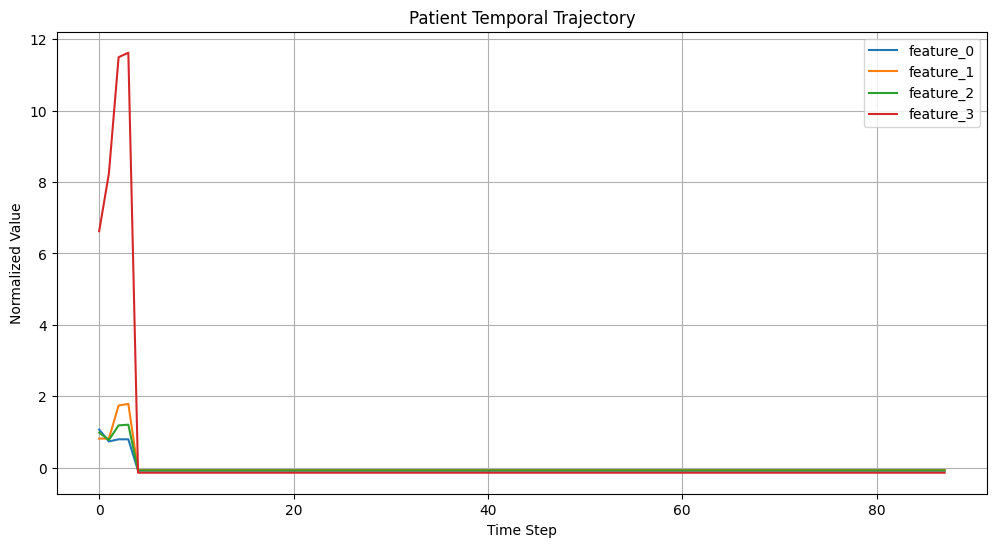

In [ ]:
patient_df = pd.DataFrame(patient_x, columns=[f"feature_{i}" for i in range(num_features)])

plt.figure(figsize=(12,6))
for i in range(min(4, num_features)):
    plt.plot(patient_df.index, patient_df[f"feature_{i}"], label=f"feature_{i}")

plt.xlabel("Time Step")
plt.ylabel("Normalized Value")
plt.title("Patient Temporal Trajectory")
plt.legend()
plt.grid(True)
plt.show()

##Generate table output

In [31]:
import pandas as pd

#  safety check
if "results" not in globals():
    raise Exception("❌ 'results' not found. Run counterfactual prediction first.")

#  build summary
summary_rows = []

for tr, prob in results.items():
    summary_rows.append({
        "Treatment": treatment_names.get(tr, f"Treatment {tr}"),
        "Predicted Risk Probability": round(float(prob), 4),
        "Predicted Outcome": "Risky" if prob > 0.5 else "Stable"
    })

summary_df = pd.DataFrame(summary_rows)

#  sort (optional but better)
summary_df = summary_df.sort_values(by="Predicted Risk Probability")

summary_df.reset_index(drop=True, inplace=True)

summary_df

,Treatment,Predicted Risk Probability,Predicted Outcome
0,Treatment 4,0.0175,Stable
1,Treatment 3,0.0552,Stable
2,No Treatment,0.0656,Stable
3,Drug A,0.1643,Stable
4,Drug B,0.1930,Stable
5,Treatment 5,0.2716,Stable
